In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("News Classification Labeling - Sheet1.csv")

print("Shape:", df.shape)
print(df.head())
print("\nColumns:")
print(df.columns.tolist())

Shape: (5000, 4)
                                                 URL  \
0  https://asiatimes.com/2025/10/vietnam-airlines...   
1  https://asiatimes.com/2025/10/doj-seizes-15-bi...   
2  https://www.fool.com/investing/2025/10/15/too-...   
3  https://www.fool.com/investing/2025/10/15/inte...   
4  https://www.fool.com/investing/2025/10/15/3-ro...   

                                               Title    Category Group Leader  
0  Vietnam Airlines data leak exposes a crisis of...  Technology          NaN  
1  DOJ seizes $15 billion bitcoin in SE Asia cryp...     Markets          NaN  
2  Think It's Too Late to Buy IonQ? Here's the 1 ...     Markets          NaN  
3  Intel's Crucial Panther Lake Chips Start Produ...  Technology          NaN  
4                3 Robotics Stocks to Buy in October     Markets          NaN  

Columns:
['URL', 'Title', 'Category', 'Group Leader']


In [4]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nUnique Values:")
print(df.nunique())

print("\nCategory Distribution:")
print(df["Category"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   URL           5000 non-null   object
 1   Title         5000 non-null   object
 2   Category      4999 non-null   object
 3   Group Leader  4265 non-null   object
dtypes: object(4)
memory usage: 156.4+ KB
None

Missing Values:
URL               0
Title             0
Category          1
Group Leader    735
dtype: int64

Duplicate Rows:
0

Unique Values:
URL             5000
Title           4578
Category           6
Group Leader      16
dtype: int64

Category Distribution:
Category
Business      1896
Markets       1518
Politics       862
Technology     452
Health         144
Energy         127
Name: count, dtype: int64


In [7]:
df["Title"] = df["Title"].fillna("")
df["URL"] = df["URL"].fillna("")

# Duplicate rows remove
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)

data = df[["Title"]].copy()

print(data.head())
print(data.shape)

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

data["Clean_Title"] = data["Title"].apply(clean_text)

print(data[["Title", "Clean_Title"]].head(10))

Shape after cleaning: (5000, 4)
                                               Title
0  Vietnam Airlines data leak exposes a crisis of...
1  DOJ seizes $15 billion bitcoin in SE Asia cryp...
2  Think It's Too Late to Buy IonQ? Here's the 1 ...
3  Intel's Crucial Panther Lake Chips Start Produ...
4                3 Robotics Stocks to Buy in October
(5000, 1)
                                               Title  \
0  Vietnam Airlines data leak exposes a crisis of...   
1  DOJ seizes $15 billion bitcoin in SE Asia cryp...   
2  Think It's Too Late to Buy IonQ? Here's the 1 ...   
3  Intel's Crucial Panther Lake Chips Start Produ...   
4                3 Robotics Stocks to Buy in October   
5  Think It's Too Late to Buy Applied Digital? He...   
6                        Transcript: UK Budget blues   
7  Is Investing in Nebius Group Stock a Once-in-a...   
8     What Are 3 Great Tech Stocks to Buy Right Now?   
9  Down 27% From Its High, Is CoreWeave a Top AI ...   

                       

In [8]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2,
    max_df=0.95
)

X_tfidf = tfidf.fit_transform(data["Clean_Title"])

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (5000, 5000)


In [9]:
svd = TruncatedSVD(n_components=100, random_state=42)

X_svd = svd.fit_transform(X_tfidf)

print("SVD Shape:", X_svd.shape)

SVD Shape: (5000, 100)


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_svd)

print("Scaled Shape:", X_scaled.shape)

Scaled Shape: (5000, 100)


In [11]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

C:\Users\pk\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\pk\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\pk\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Program Files\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\Python310\lib\subprocess.py", line 971, in __init__
    self._exec

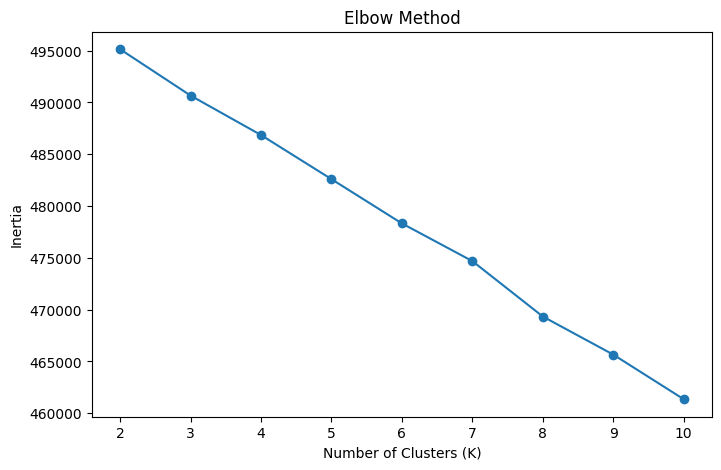

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [13]:
silhouette_scores = []

for k in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)
    
    print(f"K = {k} | Silhouette Score = {score:.4f}")

K = 2 | Silhouette Score = 0.1958
K = 3 | Silhouette Score = 0.0981
K = 4 | Silhouette Score = 0.1288
K = 5 | Silhouette Score = 0.0745
K = 6 | Silhouette Score = 0.0619
K = 7 | Silhouette Score = 0.0826
K = 8 | Silhouette Score = 0.0553
K = 9 | Silhouette Score = 0.0678
K = 10 | Silhouette Score = 0.0644


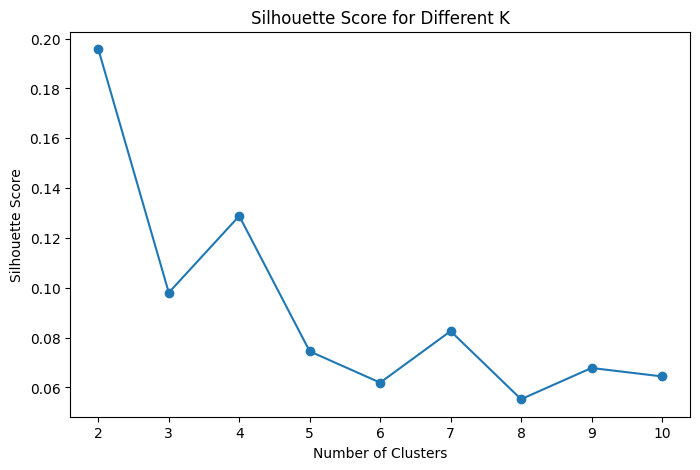

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")

plt.show()

In [15]:
best_k = 2

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

data["KMeans_Cluster"] = kmeans_labels

print(data["KMeans_Cluster"].value_counts())

KMeans_Cluster
0    4882
1     118
Name: count, dtype: int64


In [16]:
kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.19575856062479474


In [17]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

agg = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

agg_labels = agg.fit_predict(X_scaled)

data["Agglomerative_Cluster"] = agg_labels

print(data["Agglomerative_Cluster"].value_counts())

Agglomerative_Cluster
0    4968
1      32
Name: count, dtype: int64


In [18]:
agg_score = silhouette_score(
    X_scaled,
    agg_labels
)

print("Agglomerative Silhouette Score:", agg_score)

Agglomerative Silhouette Score: 0.18557623829625813


In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

data["DBSCAN_Cluster"] = dbscan_labels

print(data["DBSCAN_Cluster"].value_counts())


unique_labels = set(dbscan_labels)

if len(unique_labels - {-1}) >= 2:
    
    mask = dbscan_labels != -1
    
    dbscan_score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
    
    print("DBSCAN Silhouette Score:", dbscan_score)

else:
    print("DBSCAN ne enough clusters nahi banaye.")

DBSCAN_Cluster
-1     4779
 0      113
 6       23
 7       15
 2        9
 4        9
 11       8
 1        6
 3        6
 8        6
 9        6
 5        5
 10       5
 12       5
 13       5
Name: count, dtype: int64
DBSCAN Silhouette Score: 0.7297601527545329


In [21]:
results = pd.DataFrame({
    "Model": [
        "K-Means",
        "Agglomerative Clustering"
    ],
    "Silhouette Score": [
        kmeans_score,
        agg_score
    ]
})

if len(unique_labels - {-1}) >= 2:
    results.loc[len(results)] = [
        "DBSCAN",
        dbscan_score
    ]

print(results)

                      Model  Silhouette Score
0                   K-Means          0.195759
1  Agglomerative Clustering          0.185576
2                    DBSCAN          0.729760


In [22]:
results = results.sort_values(
    by="Silhouette Score",
    ascending=False
)

print(results)

                      Model  Silhouette Score
2                    DBSCAN          0.729760
0                   K-Means          0.195759
1  Agglomerative Clustering          0.185576


In [23]:
for cluster in sorted(data["KMeans_Cluster"].unique()):

    print("\n" + "="*70)
    print("CLUSTER:", cluster)
    print("="*70)

    cluster_data = data[
        data["KMeans_Cluster"] == cluster
    ]

    for title in cluster_data["Title"].head(15):
        print("-", title)


CLUSTER: 0
- Vietnam Airlines data leak exposes a crisis of transparency
- DOJ seizes $15 billion bitcoin in SE Asia crypto scam bust
- Think It's Too Late to Buy IonQ? Here's the 1 Reason Why There's Still Time
- Intel's Crucial Panther Lake Chips Start Production
- 3 Robotics Stocks to Buy in October
- Think It's Too Late to Buy Applied Digital? Here's 1 Reason Why There's Still Time.
- Transcript: UK Budget blues
- Is Investing in Nebius Group Stock a Once-in-a-Lifetime Opportunity?
- What Are 3 Great Tech Stocks to Buy Right Now?
- Down 27% From Its High, Is CoreWeave a Top AI Stock to Buy Right Now?
- Navitas Investors Need to Know This Before Q3 Earnings
- Is SoFi Technologies Stock a Buy After the Pullback?
- 3 Sneaky Quantum AI Stocks to Buy Now
- Should You Buy Google Stock Before Oct. 29?
- Does Billionaire Ken Griffin Know Something Wall Street Doesn't? The Citadel Chief Sold 48% of His Stake in Palantir and Is Piling Into This Stock-Split Stock Instead.

CLUSTER: 1
- Reyno

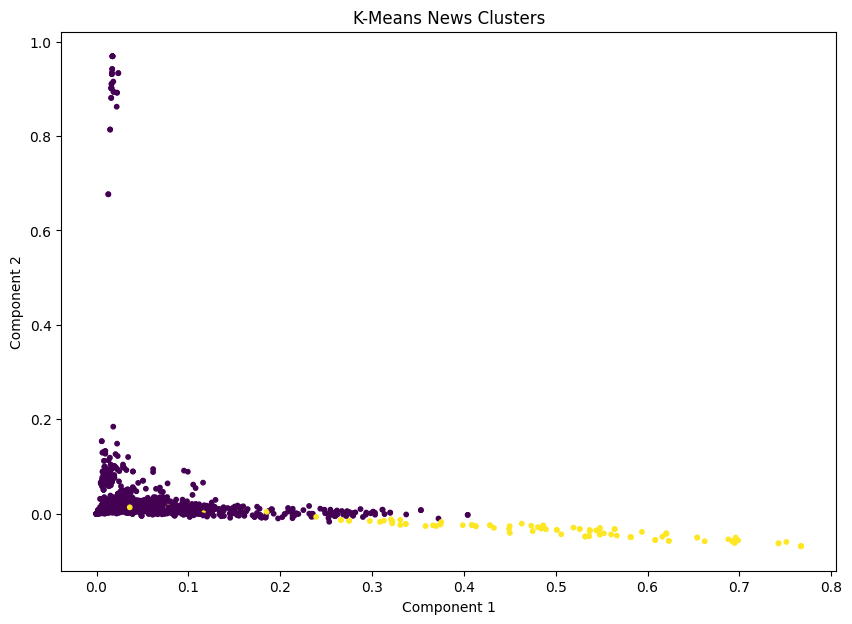

In [24]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

svd_2d = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_2d = svd_2d.fit_transform(X_tfidf)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=kmeans_labels,
    s=10
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("K-Means News Clusters")

plt.show()

In [25]:
print("DBSCAN Cluster Distribution:")
print(data["DBSCAN_Cluster"].value_counts().sort_index())

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

DBSCAN Cluster Distribution:
DBSCAN_Cluster
-1     4779
 0      113
 1        6
 2        9
 3        6
 4        9
 5        5
 6       23
 7       15
 8        6
 9        6
 10       5
 11       8
 12       5
 13       5
Name: count, dtype: int64
Number of clusters: 14
Number of noise points: 4779
